So far we've just stacked the seismograms from individual LFEs and looked at the stacks.  But here cross-correlate the individual seismograms with the stacks to estimate properties of individual events.

In [1]:
import numpy as np
import obspy
import lfeanalysis
import matplotlib.pyplot as plt
from importlib import reload
reload(lfeanalysis)

<module 'lfeanalysis' from '/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py'>

### 1. Load and prepare the data

As usual, we first read in the data and do some grouping by time.

In [2]:
# as before, we need to initialize an analysis object
lf=lfeanalysis.lfanalyse(fnum=156)

# and load in the detections and waveforms
lf.load_prep_data(flm=[1,8],single_norm=False)

Reading data
Normalizing data
Filtering data


### 2. Stack

Then we make an initial stack.

In [3]:
# stack for each group
lf.stack_by_group()

# and pick arrival times
lf.pick_stacks(minsnr=10)

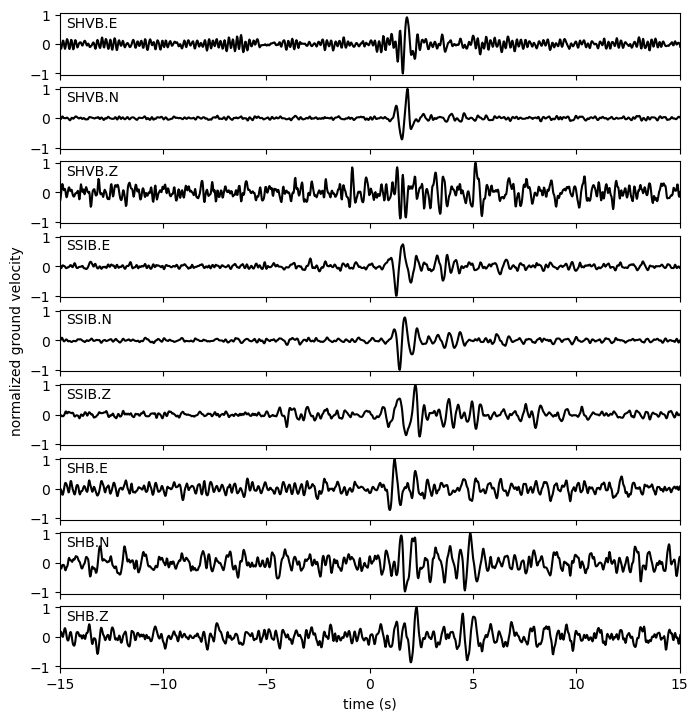

In [4]:
# have a look at what we get
lf.plot_stacks(stn=['SSIB','SHVB','SHB'])

### 3. Compare the stack with individual records

Next though, we cross-correlate the stack at each station with the seismograms from individual LFEs.

In [5]:
# all the cross-correlations
lf.xc_with_stack()

/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py:2289: RuntimeWarning: invalid value encountered in multiply
  self.xc=np.ndarray([Nshf,Nev,Nstat,Ncmps],dtype=float)*float('nan')
/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py:2380: RuntimeWarning: Mean of empty slice
  xcbystat=np.nanmean(self.xc,axis=3)
/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py:2381: RuntimeWarning: Mean of empty slice
  xcmean=np.nanmean(xcbystat,axis=2)


xc shape (9, 1658, 9, 3)


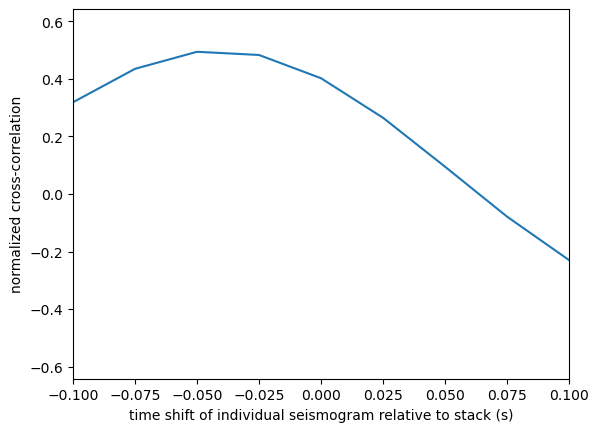

In [6]:
# we can examine several results of this cross-correlation
# lf.xc has all of the values
# it has shape [# of time shifts, # of LFEs, # of stations considered, # number of components]
print('xc shape',lf.xc.shape)

# let's pick an LFE, station, and component to consider
kstat,kcmp=5,0
iok=np.where(~np.isnan(lf.xc[0,:,kstat,kcmp]))[0]
klfe=iok[15]

# we can plot the cross-correlation between the seismogram and the stack
# as a function of their time shift
plt.plot(lf.xctim,lf.xc[:,klfe,kstat,kcmp]);
plt.xlabel('time shift of individual seismogram relative to stack (s)');
plt.ylabel('normalized cross-correlation');
plt.xlim([np.min(lf.xctim),np.max(lf.xctim)]);
plt.ylim(np.array([-1,1])*np.max(np.abs(lf.xc[:,klfe,kstat,kcmp]))*1.3);

/tmp/ipykernel_1225837/3103150234.py:7: RuntimeWarning: Mean of empty slice
  xcm=np.nanmean(np.nanmean(lf.xc[:,klfe,:,:],axis=2),axis=1)


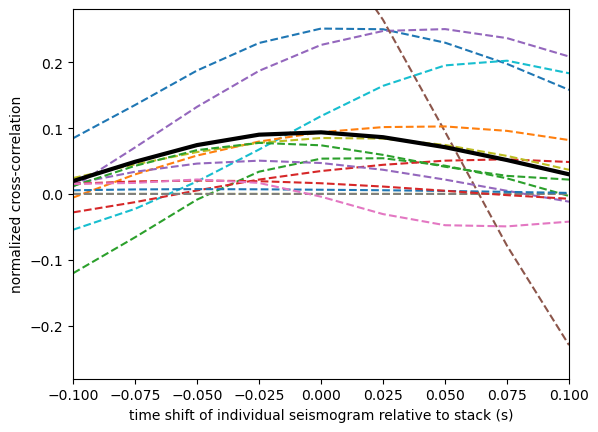

In [7]:
# or we could average the cross-correlations over stations and components 
# before plotting as a function of time shifts
# we can plot the cross-correlation between the seismogram and the stack
# as a function of their time shift
for kc in range(0,lf.xc_cmps.size):
    plt.plot(lf.xctim,lf.xc[:,klfe,:,kc],linestyle='--');
xcm=np.nanmean(np.nanmean(lf.xc[:,klfe,:,:],axis=2),axis=1)
plt.plot(lf.xctim,xcm,color='k',linewidth=3);
plt.xlabel('time shift of individual seismogram relative to stack (s)');
plt.ylabel('normalized cross-correlation');
plt.xlim([np.min(lf.xctim),np.max(lf.xctim)]);
plt.ylim(np.array([-1,1])*np.nanmax(np.abs(xcm).flatten())*3);

Note that the cross-correlations obtained from individual seismograms are often poor, but you get more significant results by averaging over stations.

### 4. Examine the stack-normalized cross-correlations

The cross-correlations obtained above are fully normalized.  That means if we were comparing a portion of the individual seismogram $v_i(t)$ with a portion of the stack $v_s(t)$, we'd compute

$$x = \frac{\sum_k {v_i(t_k) v_s(t_k)} } {\sqrt{\sum_k v^2_i(t_k)\sum_k v^2_s(t_k)}}. $$

So multiplying at each time step $k$ and summing, and then normalizing by the power in the stack _and_ the power in the individual seismogram.

But if we wanted to know the value we'd have to multiply by to get from the stack to the seismogram, we could instead compute

$$A = \frac{\sum_k {v_i(t_k) v_s(t_k)} } {\sum_k v^2_s(t_k)}, $$

where we just normalize by the stack's power.

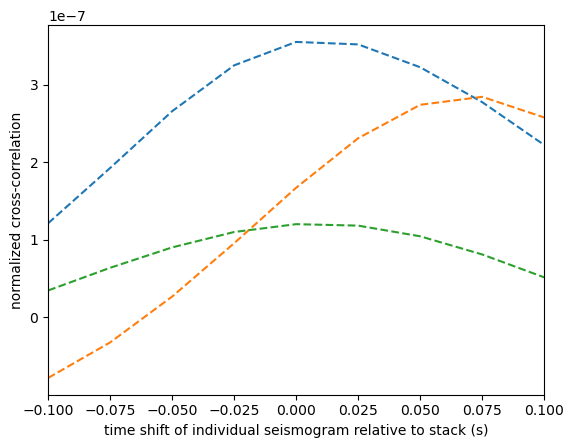

In [8]:
# this stack-normalized cross-correlation is saved in lf.xcamp
# it has the same shape and dimensions as lf.xc
# but the values are very different
# they are the values needed to map the stack in lf.totstk,
# with its arbitrary normalization, to the seismograms
kstat=0
plt.plot(lf.xctim,lf.xcamp[:,klfe,kstat,:],linestyle='--');
plt.xlabel('time shift of individual seismogram relative to stack (s)');
plt.ylabel('normalized cross-correlation');
plt.xlim([np.min(lf.xctim),np.max(lf.xctim)]);
#plt.ylim(np.array([-1,1])*np.nanmax(np.abs(xcm).flatten())*3);

Note that different stations are different distances from the LFE, so they may have very different amplitudes.   Also, not all stations record all LFEs, so there's no guarantee that the normalization should be consistent. It makes sense to average the fully normalized cross-correlations over stations, but there's no reason to average the stack-normalized cross-correlations over stations.

It's probably okay to average the stack-normalized x-c over components, as all the components at a given station are normalized by the same value before the stack averaging.

### 5. Find the time shift that give the highest x-c

We can now find the time shift that gives the highest (fully normalized) cross-correlation.

txcmax (1658,) [ 0.    -0.025 -0.025 ... -0.025  0.025  0.025]
xcmax (1658,) [0.0136809  0.04923581 0.04654608 ... 0.08901141 0.04546469 0.0233884 ]


/tmp/ipykernel_1225837/3362181276.py:9: RuntimeWarning: Mean of empty slice
  xcm=np.nanmean(np.nanmean(lf.xc[:,klfe,:,:],axis=2),axis=1)


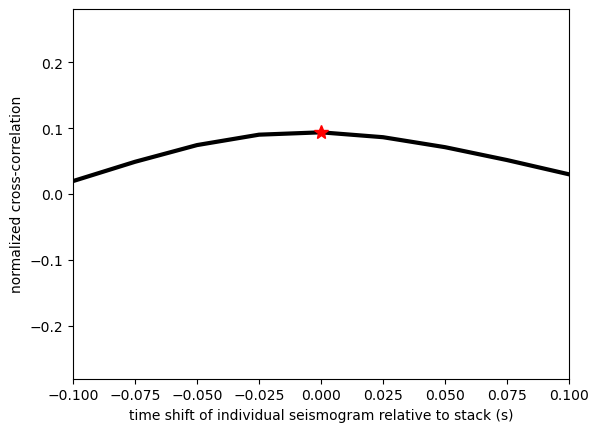

In [9]:
# the time shift that gives the highest correlation for each LFE is saved in lf.txcmax
# this is after averaging over components and stations
print('txcmax',lf.txcmax.shape,lf.txcmax)

# the values of those cross-correlations are in lf.xcmax
print('xcmax',lf.xcmax.shape,lf.xcmax)

# we can check this is correct for one LFE
xcm=np.nanmean(np.nanmean(lf.xc[:,klfe,:,:],axis=2),axis=1)
plt.plot(lf.xctim,xcm,color='k',linewidth=3);
plt.plot(lf.txcmax[klfe],lf.xcmax[klfe],marker='*',color='red',markersize=10);
plt.xlabel('time shift of individual seismogram relative to stack (s)');
plt.ylabel('normalized cross-correlation');
plt.xlim([np.min(lf.xctim),np.max(lf.xctim)]);
plt.ylim(np.array([-1,1])*np.nanmax(np.abs(xcm).flatten())*3);

### 6. Find the per-station LFE amplitude at the best time shift

We can grab out the best LFE amplitude for each LFE and station by grabbing the best-fitting value at each station.

In [10]:
# for instance, find the time index for the LFE we've been considering
ix=np.argmin(np.abs(lf.xctim-lf.txcmax[klfe]))

# and grab the amplitude at a given station and component
print('The amplitudes for LFE {:d} at station {:s} are '.format(klfe,lf.xc_stns[kstat]))
print('by component: ',lf.xcamp[ix,klfe,kstat,:])
print('and averaged over components: ',np.mean(lf.xcamp[ix,klfe,kstat,:]))

# the component averaged amplitudes are saved in lf.allamps
# which has dimensions [# of LFEs by # of stations]
print('allamps',lf.allamps.shape)

# check the average here
print('Saved average: ',lf.allamps[klfe,kstat])

The amplitudes for LFE 1207 at station B926 are 
by component:  [3.55167555e-07 1.67131369e-07 1.20133384e-07]
and averaged over components:  2.1414410263850528e-07
allamps (1658, 9)
Saved average:  2.1414410263850528e-07


### 7. Estimate one amplitude per LFE

Of course, we don't really one a different amplitude for each LFE at each station.  The observed amplitude of LFE $j$ at station $l$ is equal to 

$$\textrm{amplitude (sort of moment) of LFE }j \times \textrm{path effect amplitude of station }l$$

So let's find a set of LFE amplitudes and path effect amplitudes that match the per-station amplitudes.

In [11]:
reload(lfeanalysis)
lf=lfeanalysis.lfanalyse(lfi=lf)

# this iteratively computes the median among stations and among LFEs to get 
# LFE and path effect amplitudes
lf.normalize_amplitudes()

# the path effect amplitudes
print('Path effect amplitudes',lf.statamp.shape,lf.statamp)

# the LFE amplitudes
print('\nLFE amplitudes',lf.evamp.shape,lf.evamp)

Path effect amplitudes (9,) [1.21787618e-07 2.18678467e-07 1.78001369e-07 1.73742690e-07
 1.14825055e-07 2.96318367e-07 4.96133474e-08 1.58646533e-07
 1.60057210e-07]

LFE amplitudes (1658,) [0.36478666 0.88159781 0.70849114 ... 1.46106517 0.43129762 0.06619554]


/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py:2412: RuntimeWarning: All-NaN slice encountered
  evamp=np.nanmedian(np.divide(self.allamps,statamp),axis=1,


### 8. Recompute the stacks, weighting by LFE amplitude

It may now be interesting to redo the stacks, this time weighting the seismogram from each LFE by that LFE's amplitude, so that bigger LFEs contribute more.

In [12]:
# first save a copy of the previous stack
stack1=lf.totstk.copy()

# and restack
lf.stack_by_group(weighting='over_max_with_amp')
lf.pick_stacks(minsnr=10)

/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py:839: RuntimeWarning: invalid value encountered in multiply
  self.grpstkb[ky][idi]=np.ndarray([nvl,Nboot])*float('nan')
/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py:842: RuntimeWarning: invalid value encountered in multiply
  self.totstkb[idi]=np.ndarray([nvl,Nboot])*float('nan')


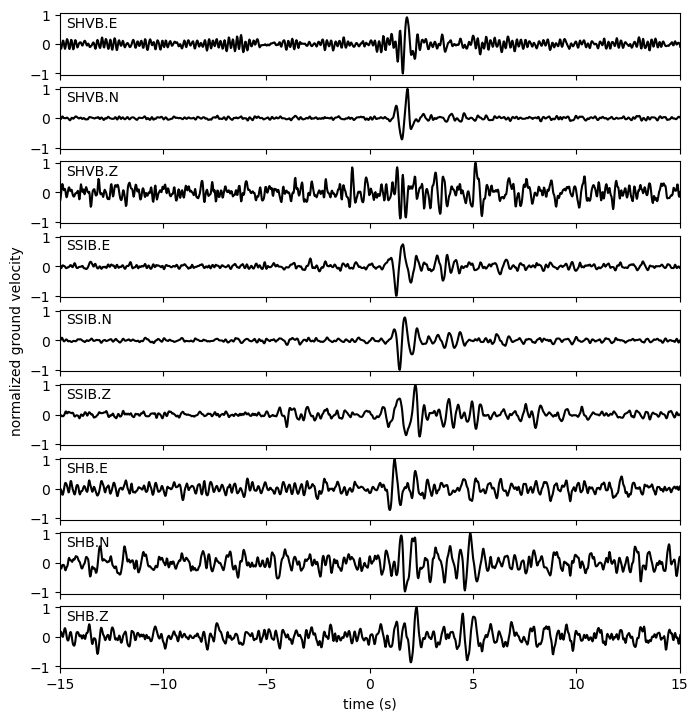

In [13]:
# have a look at what we get this time
lf.plot_stacks(stn=['SSIB','SHVB','SHB'])

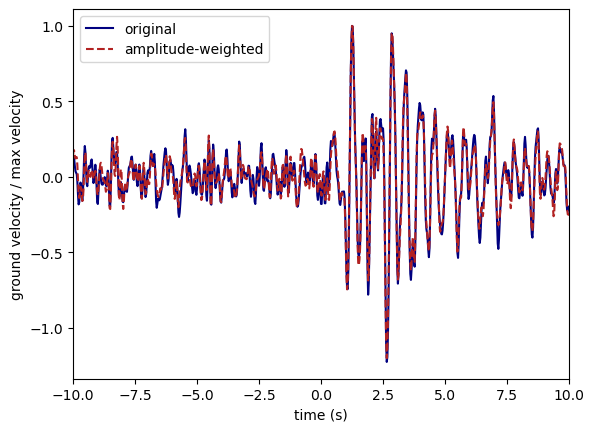

In [14]:
# and compare
tr_orig=stack1.select(station='B926',channel='N')[0]
tr_new=lf.totstk.select(station='B926',channel='N')[0]

plt.plot(tr_orig.times()-tr_new.stats.t0,tr_orig.data/np.max(tr_orig.data),color='navy',
         label='original');
plt.plot(tr_new.times()-tr_new.stats.t0,tr_new.data/np.max(tr_new.data),color='firebrick',
         label='amplitude-weighted',linestyle='--');
plt.xlim([-10,10]);
plt.xlabel('time (s)');
plt.ylabel('ground velocity / max velocity');
plt.legend();

The results are pretty similar. Comparing the amplitude seismogram during the LFE to a time interval beforehand suggests that the amplitude weighting only marginally changes the signal to noise ratio.